## 1. Check GPU, RAM, and disk

Run this first to confirm whether Kaggle has a GPU attached and enough RAM/disk space.

In [1]:
import os
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("No GPU detected. On Kaggle: Settings → Accelerator → GPU.")

print("\nRAM:")
!free -h

print("\nDisk:")
!df -h /kaggle/working


CUDA available: True
GPU: Tesla T4

RAM:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.0Gi        27Gi       1.0Mi       3.3Gi        29Gi
Swap:             0B          0B          0B

Disk:
Filesystem      Size  Used Avail Use% Mounted on
/dev/loop1       20G  184K   20G   1% /kaggle/working


## 2. Locate the Kaggle dataset

This replaces the old Colab/Kaggle-API download cells. On Kaggle, use **Add Input** instead of downloading the dataset inside the notebook.

In [2]:
import os
from pathlib import Path

KAGGLE_INPUT = Path("/kaggle/input")
OUTPUT_ROOT = Path("/kaggle/working/noisy_drone_yolov5_signalbox")
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Find dataset.pt automatically so the notebook still works if Kaggle changes the mounted folder name.
candidates = list(KAGGLE_INPUT.rglob("dataset.pt"))
if not candidates:
    raise FileNotFoundError(
        "Could not find dataset.pt under /kaggle/input. "
        "Click Add Input and attach sgluege/noisy-drone-rf-signal-classification first."
    )

DATA_PATH = candidates[0]
DATA_DIR = DATA_PATH.parent

class_stats_path = DATA_DIR / "class_stats.csv"
snr_stats_path = DATA_DIR / "SNR_stats.csv"

print("DATA_DIR:", DATA_DIR)
print("DATA_PATH:", DATA_PATH)
print("File size GB:", DATA_PATH.stat().st_size / 1024**3)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

print("\nFiles in DATA_DIR:")
for p in sorted(DATA_DIR.iterdir()):
    print("-", p.name)


DATA_DIR: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification
DATA_PATH: /kaggle/input/datasets/sgluege/noisy-drone-rf-signal-classification/dataset.pt
File size GB: 24.099373045377433
OUTPUT_ROOT: /kaggle/working/noisy_drone_yolov5_signalbox

Files in DATA_DIR:
- SNR_stats.csv
- class_stats.csv
- dataset.pt


## 3. Inspect class and SNR statistics

This shows the class imbalance and SNR distribution.


In [3]:
import pandas as pd

class_stats = pd.read_csv(class_stats_path)
snr_stats = pd.read_csv(snr_stats_path)

print("Class stats:")
display(class_stats)

print("SNR stats:")
display(snr_stats)


Class stats:


,Unnamed: 0,class,class_int,count
0,0,DJI,0,2194
1,1,FutabaT14,1,6938
2,2,FutabaT7,2,3661
3,3,Graupner,3,6481
4,4,Noise,4,52552
5,5,Taranis,5,16546
6,6,Turnigy,6,10333


SNR stats:


,Unnamed: 0,SNR,count
0,0,-20,3792
1,1,-18,3795
2,2,-16,3796
3,3,-14,3796
4,4,-12,3797
5,5,-10,3796
6,6,-8,3795
7,7,-6,3795
8,8,-4,3798
9,9,-2,3798


## 4. Safely load `dataset.pt` with memory mapping

`dataset.pt` is large, so normal `torch.load()` can use too much RAM. This notebook uses `mmap=True` to avoid loading everything into memory at once.

In [4]:
import torch

print("Before loading:")
!free -h

data = torch.load(
    DATA_PATH,
    map_location="cpu",
    mmap=True,
    weights_only=False
)

print("Loaded successfully with mmap")
print("Type:", type(data))

for k, v in data.items():
    print(k, type(v), getattr(v, "shape", None), getattr(v, "dtype", None))

print("After loading:")
!free -h


Before loading:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.0Gi        26Gi       1.0Mi       3.4Gi        29Gi
Swap:             0B          0B          0B
Loaded successfully with mmap
Type: <class 'dict'>
x_iq <class 'torch.Tensor'> torch.Size([98705, 2, 16384]) torch.float32
x_spec <class 'torch.Tensor'> torch.Size([98705, 2, 128, 128]) torch.float32
y <class 'torch.Tensor'> torch.Size([98705]) torch.int64
snr <class 'torch.Tensor'> torch.Size([98705]) torch.int32
duty_cycle <class 'torch.Tensor'> torch.Size([98705]) torch.float32
After loading:
               total        used        free      shared  buff/cache   available
Mem:            31Gi       1.0Gi        26Gi       1.0Mi       3.4Gi        29Gi
Swap:             0B          0B          0B


## 5. Create a balanced 7-class subset for YOLOv5

The full dataset is imbalanced because the `Noise` class is much larger than the smallest class.

For a fair first experiment, use:

- 1700 training samples per class
- 400 validation samples per class
- 7 classes total

For YOLOv5 training, `Noise` samples are still included, but their label files are empty because noise is treated as background.


In [5]:
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

class_names = [
    "DJI",
    "FutabaT14",
    "FutabaT7",
    "Graupner",
    "Noise",
    "Taranis",
    "Turnigy"
]

y = data["y"]

# Set QUICK_TEST = True for a short pipeline test before using GPU quota on a full run.
QUICK_TEST = False

if QUICK_TEST:
    train_per_class = 300
    valid_per_class = 100
else:
    train_per_class = 1794
    valid_per_class = 400

train_indices = []
valid_indices = []

for cls, name in enumerate(class_names):
    cls_indices = torch.where(y == cls)[0].cpu().numpy()
    np.random.shuffle(cls_indices)

    needed = train_per_class + valid_per_class
    if len(cls_indices) < needed:
        raise ValueError(f"Class {name} has only {len(cls_indices)} samples, but {needed} are needed.")

    train_indices.extend(cls_indices[:train_per_class])
    valid_indices.extend(cls_indices[train_per_class:train_per_class + valid_per_class])

train_indices = np.array(train_indices)
valid_indices = np.array(valid_indices)

np.random.shuffle(train_indices)
np.random.shuffle(valid_indices)

print("Train samples:", len(train_indices))
print("Valid samples:", len(valid_indices))

for cls, name in enumerate(class_names):
    train_count = int((y[train_indices] == cls).sum().item())
    valid_count = int((y[valid_indices] == cls).sum().item())
    print(f"{name}: train={train_count}, valid={valid_count}")


Train samples: 12558
Valid samples: 2800
DJI: train=1794, valid=400
FutabaT14: train=1794, valid=400
FutabaT7: train=1794, valid=400
Graupner: train=1794, valid=400
Noise: train=1794, valid=400
Taranis: train=1794, valid=400
Turnigy: train=1794, valid=400


## 6. YOLOv5 architecture setup — automatic signal-region boxes

This is the architecture replacement: instead of defining a PyTorch ResNet class, the notebook prepares YOLOv5 training data and then trains the YOLOv5 architecture from the official YOLOv5 code.

Instead of giving every spectrogram a full-image box, this version creates a box around the estimated high-power RF signal region.

Pipeline:

```text
x_spec [2, 128, 128]
    -> grayscale spectrogram PNG
    -> threshold high-power pixels
    -> connected-component box
    -> YOLOv5 label file
```

Important: **Noise is not an object class**. Noise images get empty label files.


In [6]:
from pathlib import Path
import os
import shutil
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm
from PIL import Image

# YOLO output folder. Kaggle saves /kaggle/working outputs automatically.
YOLO_DIR = OUTPUT_ROOT

IMG_TRAIN = YOLO_DIR / "images" / "train"
IMG_VALID = YOLO_DIR / "images" / "valid"
LBL_TRAIN = YOLO_DIR / "labels" / "train"
LBL_VALID = YOLO_DIR / "labels" / "valid"

# Clear exported image/label folders so rerunning with QUICK_TEST changed does not leave stale files.
for folder in [IMG_TRAIN, IMG_VALID, LBL_TRAIN, LBL_VALID]:
    if folder.exists():
        shutil.rmtree(folder)
    folder.mkdir(parents=True, exist_ok=True)

# In object detection, Noise should be background, not an object class.
NOISE_CLASS_ID = class_names.index("Noise")

yolo_class_names = [name for name in class_names if name != "Noise"]

# Map original 7-class IDs -> YOLO object IDs.
# Example: original class 5 may become YOLO class 4 if Noise was removed.
orig_to_yolo = {}
yolo_to_orig = {}

new_id = 0
for old_id, name in enumerate(class_names):
    if old_id == NOISE_CLASS_ID:
        continue
    orig_to_yolo[old_id] = new_id
    yolo_to_orig[new_id] = old_id
    new_id += 1

print("Original 7 class names:", class_names)
print("YOLO object class names:", yolo_class_names)
print("Noise class ID:", NOISE_CLASS_ID)
print("Original -> YOLO class map:", orig_to_yolo)
print("YOLO dataset folder:", YOLO_DIR)


Original 7 class names: ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Noise', 'Taranis', 'Turnigy']
YOLO object class names: ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Taranis', 'Turnigy']
Noise class ID: 4
Original -> YOLO class map: {0: 0, 1: 1, 2: 2, 3: 3, 5: 4, 6: 5}
YOLO dataset folder: /kaggle/working/noisy_drone_yolov5_signalbox


### 6.1 Convert `x_spec` into images and estimate signal boxes

The function below:

1. combines the 2-channel spectrogram into one power image,
2. thresholds high-power pixels,
3. groups connected high-power regions,
4. draws one YOLO box around the detected signal region.

You can tune these values later:

```python
percentile=90
std_factor=0.75
padding=3
```

Lower `percentile` if the signal is weak and the box is too small.
Increase `percentile` if the box is too large.


In [7]:
from scipy import ndimage

def spec_tensor_to_uint8_image(x):
    """
    Convert one x_spec tensor with shape [2, 128, 128] into a grayscale uint8 image.

    The two channels are combined as magnitude:
        sqrt(channel_0^2 + channel_1^2)

    Output:
        img_uint8: [H, W], dtype uint8, range 0..255
        img_float: [H, W], dtype float32, range 0..1
    """
    x = x.detach().float().cpu()

    if x.ndim != 3:
        raise ValueError(f"Expected x with shape [C,H,W], got {tuple(x.shape)}")

    if x.shape[0] == 2:
        img = torch.sqrt(x[0] ** 2 + x[1] ** 2)
    else:
        img = x[0]

    img = img.numpy().astype(np.float32)

    # Robust normalization so a few extreme pixels do not dominate everything.
    lo, hi = np.percentile(img, [1, 99])
    img = np.clip(img, lo, hi)
    img = img - img.min()

    if img.max() > 0:
        img = img / img.max()

    img_float = img.astype(np.float32)
    img_uint8 = (img_float * 255).astype(np.uint8)
    return img_uint8, img_float


def yolo_box_from_signal_region(
    img_float,
    percentile=90,
    std_factor=0.75,
    min_component_area=8,
    padding=3,
    fallback_full_box=True,
):
    """
    Estimate one YOLO bounding box around the high-power signal region.

    Returns:
        (x_center, y_center, width, height), all normalized to 0..1

    Notes:
    - x direction = time axis / image columns
    - y direction = frequency axis / image rows
    """
    h, w = img_float.shape

    threshold_percentile = np.percentile(img_float, percentile)
    threshold_std = img_float.mean() + std_factor * img_float.std()
    threshold = max(threshold_percentile, threshold_std)

    mask = img_float >= threshold

    # Connect nearby high-power pixels and reduce tiny isolated noise.
    mask = ndimage.binary_closing(mask, iterations=1)
    mask = ndimage.binary_dilation(mask, iterations=1)

    labeled, num_features = ndimage.label(mask)

    keep_mask = np.zeros_like(mask, dtype=bool)

    if num_features > 0:
        component_ids, component_counts = np.unique(labeled[labeled > 0], return_counts=True)

        for component_id, area in zip(component_ids, component_counts):
            if area >= min_component_area:
                keep_mask[labeled == component_id] = True

    rows, cols = np.where(keep_mask)

    # Fallback: use the brightest pixels if connected-component filtering removed everything.
    if len(rows) == 0 or len(cols) == 0:
        fallback_mask = img_float >= np.percentile(img_float, 97)
        rows, cols = np.where(fallback_mask)

    # Last fallback: full image box.
    if len(rows) == 0 or len(cols) == 0:
        if fallback_full_box:
            return 0.5, 0.5, 1.0, 1.0
        return None

    y1 = max(0, int(rows.min()) - padding)
    y2 = min(h - 1, int(rows.max()) + padding)
    x1 = max(0, int(cols.min()) - padding)
    x2 = min(w - 1, int(cols.max()) + padding)

    box_w = max(1, x2 - x1 + 1)
    box_h = max(1, y2 - y1 + 1)

    x_center = (x1 + x2 + 1) / 2 / w
    y_center = (y1 + y2 + 1) / 2 / h
    norm_w = box_w / w
    norm_h = box_h / h

    # Clip for safety.
    x_center = float(np.clip(x_center, 0.0, 1.0))
    y_center = float(np.clip(y_center, 0.0, 1.0))
    norm_w = float(np.clip(norm_w, 1.0 / w, 1.0))
    norm_h = float(np.clip(norm_h, 1.0 / h, 1.0))

    return x_center, y_center, norm_w, norm_h


# Quick test on one sample.
test_idx = int(train_indices[0])
test_img_uint8, test_img_float = spec_tensor_to_uint8_image(data["x_spec"][test_idx])
test_box = yolo_box_from_signal_region(test_img_float)
print("Test image shape:", test_img_uint8.shape)
print("Test YOLO box:", test_box)
print("Test original class:", int(data["y"][test_idx]), class_names[int(data["y"][test_idx])])

Test image shape: (128, 128)
Test YOLO box: (0.5, 0.5, 1.0, 1.0)
Test original class: 5 Taranis


### 6.2 Export YOLO dataset with automatic signal boxes

This creates:

```text
/kaggle/working/noisy_drone_yolov5_signalbox/
├── images/train
├── images/valid
├── labels/train
├── labels/valid
├── data.yaml
├── train_ground_truth.csv
└── valid_ground_truth.csv
```

For drone/controller classes, each label file gets one signal-region box.
For `Noise`, the label file is empty.


In [8]:
def export_yolo_split_signal_boxes(indices, split_name, img_dir, label_dir):
    """
    Export a split into YOLOv5 format.

    For drone/controller classes:
        writes one label line:
        yolo_class_id x_center y_center width height

    For Noise:
        writes an empty label file.
    """
    records = []

    for out_idx, real_idx in enumerate(tqdm(indices, desc=f"Exporting YOLO {split_name}")):
        real_idx = int(real_idx)

        x = data["x_spec"][real_idx]
        original_label = int(data["y"][real_idx].item())
        snr_value = float(data["snr"][real_idx].item())

        img_uint8, img_float = spec_tensor_to_uint8_image(x)

        image_name = f"{split_name}_{out_idx:06d}.png"
        label_name = f"{split_name}_{out_idx:06d}.txt"

        image_path = img_dir / image_name
        label_path = label_dir / label_name

        # Save as RGB PNG because YOLOv5 expects normal image files.
        Image.fromarray(img_uint8).convert("RGB").save(image_path)

        if original_label == NOISE_CLASS_ID:
            # Noise is background, so there is no object box.
            label_path.write_text("")
            yolo_label = -1
            box = None
        else:
            yolo_label = orig_to_yolo[original_label]
            box = yolo_box_from_signal_region(img_float)

            if box is None:
                label_path.write_text("")
            else:
                x_center, y_center, width, height = box
                label_path.write_text(
                    f"{yolo_label} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}\n"
                )

        records.append({
            "image_name": image_name,
            "label_name": label_name,
            "real_idx": real_idx,
            "original_label": original_label,
            "original_name": class_names[original_label],
            "yolo_label": yolo_label,
            "yolo_name": "background_noise" if yolo_label == -1 else yolo_class_names[yolo_label],
            "snr": snr_value,
        })

    return pd.DataFrame(records)


train_gt = export_yolo_split_signal_boxes(train_indices, "train", IMG_TRAIN, LBL_TRAIN)
valid_gt = export_yolo_split_signal_boxes(valid_indices, "valid", IMG_VALID, LBL_VALID)

train_gt_path = YOLO_DIR / "train_ground_truth.csv"
valid_gt_path = YOLO_DIR / "valid_ground_truth.csv"

train_gt.to_csv(train_gt_path, index=False)
valid_gt.to_csv(valid_gt_path, index=False)

print("Train YOLO rows:", len(train_gt))
print("Valid YOLO rows:", len(valid_gt))
print("Saved:", train_gt_path)
print("Saved:", valid_gt_path)

print("\nTrain class counts:")
display(train_gt["original_name"].value_counts())

print("\nValid class counts:")
display(valid_gt["original_name"].value_counts())

Exporting YOLO valid: 100%|██████████| 2800/2800 [00:29<00:00, 95.95it/s]


Train YOLO rows: 12558
Valid YOLO rows: 2800
Saved: /kaggle/working/noisy_drone_yolov5_signalbox/train_ground_truth.csv
Saved: /kaggle/working/noisy_drone_yolov5_signalbox/valid_ground_truth.csv

Train class counts:


original_name
Taranis      1794
FutabaT7     1794
DJI          1794
FutabaT14    1794
Turnigy      1794
Noise        1794
Graupner     1794
Name: count, dtype: int64


Valid class counts:


original_name
Taranis      400
Graupner     400
FutabaT7     400
Noise        400
DJI          400
FutabaT14    400
Turnigy      400
Name: count, dtype: int64

### 6.3 Create YOLOv5 `data.yaml`


In [9]:
data_yaml_path = YOLO_DIR / "data.yaml"

data_yaml_text = f"""
path: {YOLO_DIR}
train: images/train
val: images/valid

nc: {len(yolo_class_names)}
names: {yolo_class_names}
""".strip()

data_yaml_path.write_text(data_yaml_text)

print(data_yaml_path)
print(data_yaml_path.read_text())

/kaggle/working/noisy_drone_yolov5_signalbox/data.yaml
path: /kaggle/working/noisy_drone_yolov5_signalbox
train: images/train
val: images/valid

nc: 6
names: ['DJI', 'FutabaT14', 'FutabaT7', 'Graupner', 'Taranis', 'Turnigy']


### 6.4 Preview the generated signal boxes

Run this before training.  
You should see boxes around the brighter RF signal regions, not full-image boxes.


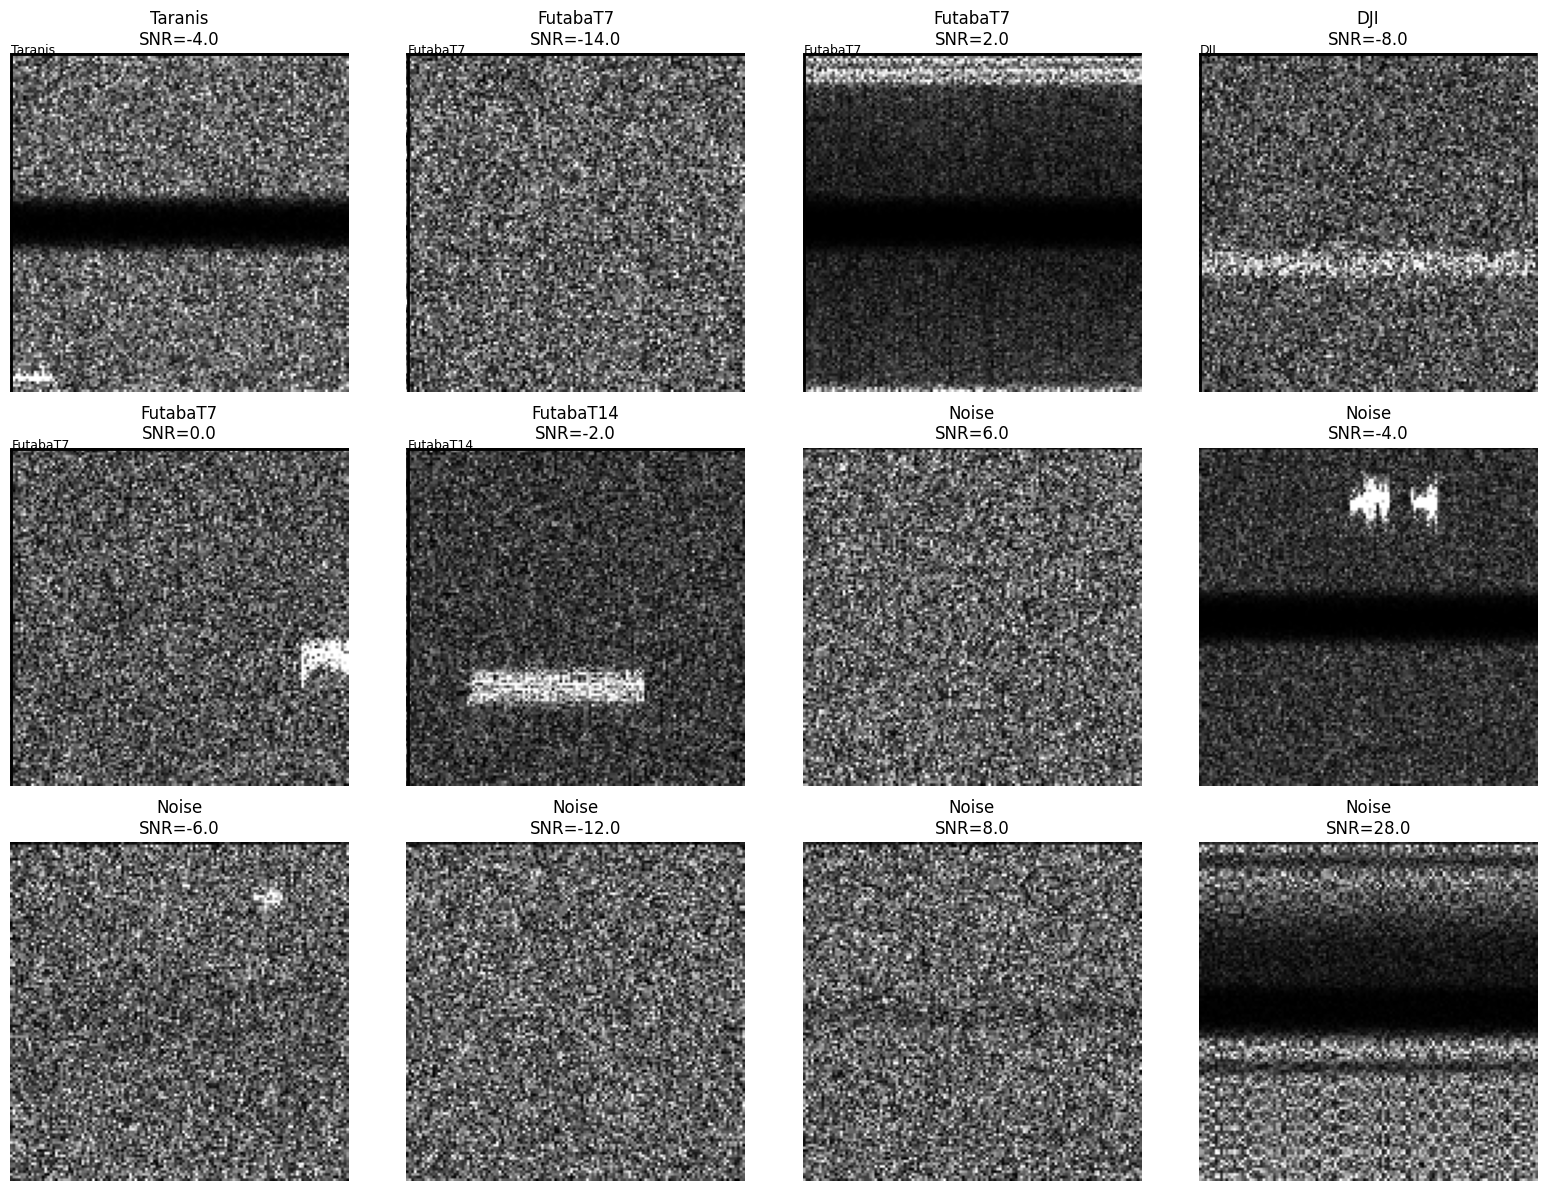

In [10]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

def read_yolo_label(label_path):
    text = Path(label_path).read_text().strip()
    if not text:
        return []

    boxes = []
    for line in text.splitlines():
        parts = line.split()
        cls_id = int(parts[0])
        x_center, y_center, width, height = map(float, parts[1:5])
        boxes.append((cls_id, x_center, y_center, width, height))
    return boxes


def preview_yolo_boxes(gt_df, img_dir, label_dir, max_images=12):
    # Mix signal and noise samples.
    preview_df = pd.concat([
        gt_df[gt_df["original_name"] != "Noise"].head(max_images // 2),
        gt_df[gt_df["original_name"] == "Noise"].head(max_images // 2),
    ]).head(max_images)

    n = len(preview_df)
    cols = 4
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(cols * 4, rows * 4))

    for plot_idx, (_, row) in enumerate(preview_df.iterrows(), start=1):
        img_path = img_dir / row["image_name"]
        label_path = label_dir / row["label_name"]

        img = np.array(Image.open(img_path))
        h, w = img.shape[:2]

        ax = plt.subplot(rows, cols, plot_idx)
        ax.imshow(img, cmap="gray")
        ax.set_title(f'{row["original_name"]}\nSNR={row["snr"]}')
        ax.axis("off")

        boxes = read_yolo_label(label_path)
        for cls_id, x_center, y_center, bw, bh in boxes:
            x1 = (x_center - bw / 2) * w
            y1 = (y_center - bh / 2) * h
            rect = Rectangle((x1, y1), bw * w, bh * h, fill=False, linewidth=2)
            ax.add_patch(rect)
            ax.text(x1, max(0, y1 - 3), yolo_class_names[cls_id], fontsize=9)

    plt.tight_layout()
    plt.show()


preview_yolo_boxes(train_gt, IMG_TRAIN, LBL_TRAIN, max_images=12)

## 7. Install YOLOv5

This cell needs internet access on Kaggle because it clones YOLOv5 from GitHub.

Use:

```text
Kaggle Notebook Settings -> Internet -> On
Accelerator -> GPU
```


In [11]:
%cd /kaggle/working

if not Path("/kaggle/working/yolov5").exists():
    !git clone https://github.com/ultralytics/yolov5.git

%cd /kaggle/working/yolov5
!pip install -q -r requirements.txt

print("YOLOv5 is ready.")

/kaggle/working
Cloning into 'yolov5'...
remote: Enumerating objects: 18248, done.
remote: Counting objects: 100% (128/128), done.
remote: Compressing objects: 100% (113/113), done.
remote: Total 18248 (delta 40), reused 31 (delta 15), pack-reused 18120 (from 1)
Receiving objects: 100% (18248/18248), 17.44 MiB | 29.67 MiB/s, done.
Resolving deltas: 100% (12386/12386), done.
/kaggle/working/yolov5
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.1/131.1 kB 9.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
dask-cuda 26.2.0 req

## 8. Train the YOLOv5 architecture

This is the replacement for the old ResNet18 training section.

Start with `yolov5n.pt`:

```text
yolov5n = nano YOLOv5 model, fastest and best for quick Kaggle tests
```

Later, try `yolov5s.pt` if you want a stronger detector and your Kaggle GPU can handle it.


In [12]:
%cd /kaggle/working/yolov5

# YOLOv5 architecture choice.
# Start with yolov5n.pt. Use yolov5s.pt later for better accuracy but slower training.
YOLO_MODEL = "yolov5n.pt"
YOLO_EPOCHS = 3 if QUICK_TEST else 30
YOLO_BATCH = 64
YOLO_IMG_SIZE = 128

!python train.py   --img {YOLO_IMG_SIZE}   --batch {YOLO_BATCH}   --epochs {YOLO_EPOCHS}   --data {data_yaml_path}   --weights {YOLO_MODEL}   --project /kaggle/working/noisy_drone_yolov5_runs   --name yolov5n_signalbox   --exist-ok


/kaggle/working/yolov5
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
wandb: WARNING ⚠️ wandb is deprecated and will be removed in a future release. See supported integrations at https://github.com/ultralytics/yolov5#integrations.
2026-06-10 08:09:55.181430: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781078995.388130      80 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781078995.445915      80 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register facto

## 9. Validate YOLOv5

This reports object-detection metrics such as precision, recall, and mAP.

Remember: this YOLO experiment has **6 object classes** because `Noise` is treated as background.


In [13]:
%cd /kaggle/working/yolov5

YOLO_BEST = Path("/kaggle/working/noisy_drone_yolov5_runs/yolov5n_signalbox/weights/best.pt")

!python val.py \
  --weights {YOLO_BEST} \
  --data {data_yaml_path} \
  --img {YOLO_IMG_SIZE} \
  --task val \
  --project /kaggle/working/noisy_drone_yolov5_val \
  --name yolov5n_signalbox_val \
  --exist-ok

/kaggle/working/yolov5
val: data=/kaggle/working/noisy_drone_yolov5_signalbox/data.yaml, weights=['/kaggle/working/noisy_drone_yolov5_runs/yolov5n_signalbox/weights/best.pt'], batch_size=32, imgsz=128, conf_thres=0.001, iou_thres=0.6, max_det=300, task=val, device=, workers=8, single_cls=False, augment=False, verbose=False, save_txt=False, save_hybrid=False, save_conf=False, save_json=False, project=/kaggle/working/noisy_drone_yolov5_val, name=yolov5n_signalbox_val, exist_ok=True, half=False, dnn=False
YOLOv5 🚀 v7.0-496-g0fd7ea49 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 1767283 parameters, 0 gradients, 4.2 GFLOPs
val: Scanning /kaggle/working/noisy_drone_yolov5_signalbox/labels/valid.cache...
                 Class     Images  Instances          P          R      mAP50   
                   all       2800       2400      0.623      0.576      0.637      0.421
                   DJI       2800        400      0.687      

## 10. Convert YOLO detections back into 7-class classification results

YOLO gives boxes, not directly one label per sample.

For classification-style evaluation:

```text
if YOLO detects a drone/controller signal:
    predicted class = highest-confidence detected object
else:
    predicted class = Noise
```

This builds a 7-class classification report and confusion matrix.


In [14]:
%cd /kaggle/working/yolov5

DETECT_PROJECT = Path("/kaggle/working/noisy_drone_yolov5_detect")
DETECT_NAME = "valid_predictions_signalbox"

!python detect.py \
  --weights {YOLO_BEST} \
  --source {IMG_VALID} \
  --img {YOLO_IMG_SIZE} \
  --conf 0.25 \
  --save-txt \
  --save-conf \
  --project {DETECT_PROJECT} \
  --name {DETECT_NAME} \
  --exist-ok

/kaggle/working/yolov5
detect: weights=['/kaggle/working/noisy_drone_yolov5_runs/yolov5n_signalbox/weights/best.pt'], source=/kaggle/working/noisy_drone_yolov5_signalbox/images/valid, data=data/coco128.yaml, imgsz=[128, 128], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_format=0, save_csv=False, save_conf=True, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=/kaggle/working/noisy_drone_yolov5_detect, name=valid_predictions_signalbox, exist_ok=True, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False, vid_stride=1
YOLOv5 🚀 v7.0-496-g0fd7ea49 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)

Fusing layers... 
Model summary: 157 layers, 1767283 parameters, 0 gradients, 4.2 GFLOPs
image 1/2800 /kaggle/working/noisy_drone_yolov5_signalbox/images/valid/valid_000000.png: 128x128 1 Taranis, 5.1ms
image 2/2800 /kaggle/working/noisy_drone_yolo

YOLO file-level accuracy: 0.7007142857142857
Saved results: /kaggle/working/noisy_drone_yolov5_signalbox/yolov5_signalbox_valid_classification_results.csv

Classification report:
              precision    recall  f1-score   support

         DJI       0.83      0.79      0.81       400
   FutabaT14       0.68      0.69      0.69       400
    FutabaT7       0.87      0.67      0.75       400
    Graupner       0.75      0.68      0.71       400
       Noise       0.47      0.95      0.63       400
     Taranis       0.88      0.67      0.76       400
     Turnigy       0.76      0.46      0.57       400

    accuracy                           0.70      2800
   macro avg       0.75      0.70      0.70      2800
weighted avg       0.75      0.70      0.70      2800



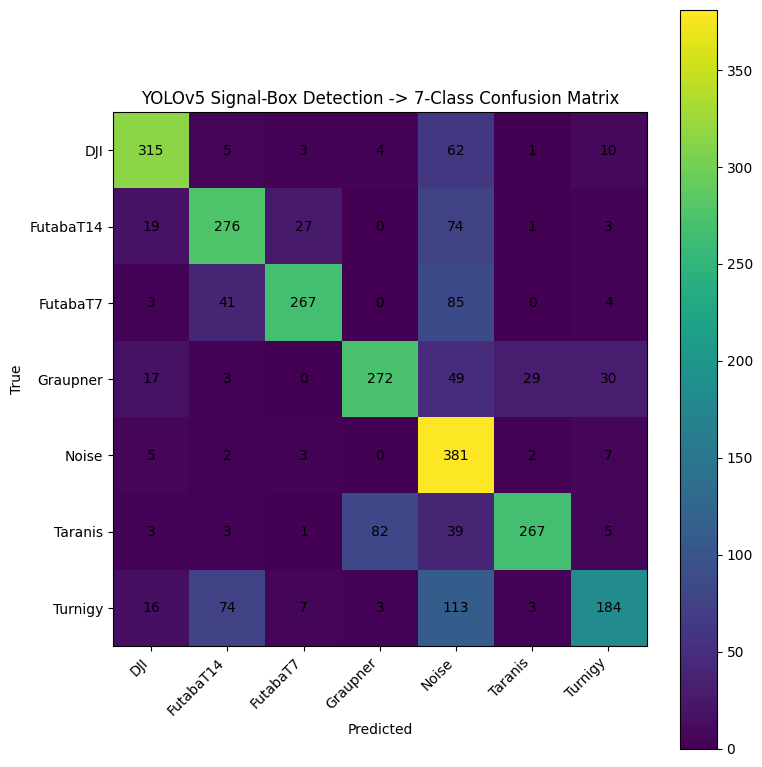

Saved confusion matrix: /kaggle/working/noisy_drone_yolov5_signalbox/yolov5_signalbox_confusion_matrix.png


,image_name,true_label,true_name,pred_label,pred_name,confidence,snr,correct
0,valid_000000.png,5,Taranis,5,Taranis,0.824501,6.0,True
1,valid_000001.png,3,Graupner,3,Graupner,0.620043,6.0,True
2,valid_000002.png,2,FutabaT7,4,Noise,0.000000,12.0,False
3,valid_000003.png,4,Noise,4,Noise,0.000000,18.0,True
4,valid_000004.png,0,DJI,4,Noise,0.000000,-20.0,False


In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

pred_label_dir = DETECT_PROJECT / DETECT_NAME / "labels"

valid_gt = pd.read_csv(YOLO_DIR / "valid_ground_truth.csv")

def predict_original_class_from_yolo_txt(image_name):
    """
    Returns:
        pred_original_class_id, confidence

    If YOLO produced no label file or no detections:
        return Noise
    """
    txt_path = pred_label_dir / (Path(image_name).stem + ".txt")

    if not txt_path.exists() or txt_path.read_text().strip() == "":
        return NOISE_CLASS_ID, 0.0

    best_conf = -1.0
    best_yolo_cls = None

    for line in txt_path.read_text().strip().splitlines():
        parts = line.split()
        yolo_cls = int(float(parts[0]))

        # detect.py --save-conf format:
        # cls x_center y_center width height confidence
        conf = float(parts[5]) if len(parts) >= 6 else 1.0

        if conf > best_conf:
            best_conf = conf
            best_yolo_cls = yolo_cls

    pred_original_cls = yolo_to_orig[best_yolo_cls]
    return pred_original_cls, best_conf


pred_rows = []
for _, row in valid_gt.iterrows():
    pred_cls, conf = predict_original_class_from_yolo_txt(row["image_name"])
    pred_rows.append({
        "image_name": row["image_name"],
        "true_label": int(row["original_label"]),
        "true_name": row["original_name"],
        "pred_label": int(pred_cls),
        "pred_name": class_names[int(pred_cls)],
        "confidence": conf,
        "snr": float(row["snr"]),
    })

yolo_cls_results = pd.DataFrame(pred_rows)
yolo_cls_results["correct"] = yolo_cls_results["true_label"] == yolo_cls_results["pred_label"]

results_path = YOLO_DIR / "yolov5_signalbox_valid_classification_results.csv"
yolo_cls_results.to_csv(results_path, index=False)

print("YOLO file-level accuracy:", yolo_cls_results["correct"].mean())
print("Saved results:", results_path)

print("\nClassification report:")
print(classification_report(
    yolo_cls_results["true_label"],
    yolo_cls_results["pred_label"],
    labels=list(range(len(class_names))),
    target_names=class_names,
    zero_division=0,
))

cm = confusion_matrix(
    yolo_cls_results["true_label"],
    yolo_cls_results["pred_label"],
    labels=list(range(len(class_names)))
)

plt.figure(figsize=(8, 8))
plt.imshow(cm)
plt.title("YOLOv5 Signal-Box Detection -> 7-Class Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(np.arange(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, int(cm[i, j]), ha="center", va="center")

plt.tight_layout()
cm_path = YOLO_DIR / "yolov5_signalbox_confusion_matrix.png"
plt.savefig(cm_path, dpi=200)
plt.show()

print("Saved confusion matrix:", cm_path)

display(yolo_cls_results.head())

## 11. YOLOv5 accuracy by SNR

This checks whether the YOLOv5 detector struggles more at low SNR and performs better at high SNR.


,SNR,accuracy
0,-20.0,0.134615
1,-18.0,0.247423
2,-16.0,0.259615
3,-14.0,0.312500
4,-12.0,0.427083
5,-10.0,0.595238
6,-8.0,0.676471
7,-6.0,0.764151
8,-4.0,0.705263
9,-2.0,0.702899


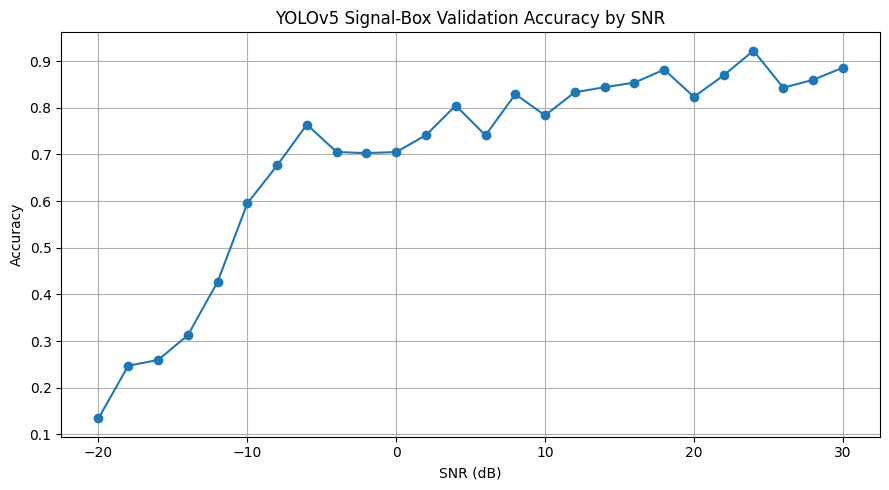

Saved: /kaggle/working/noisy_drone_yolov5_signalbox/yolov5_signalbox_accuracy_by_snr.png


In [16]:
snr_yolo_acc = yolo_cls_results.groupby("snr")["correct"].mean().reset_index()
snr_yolo_acc.columns = ["SNR", "accuracy"]

display(snr_yolo_acc)

plt.figure(figsize=(9, 5))
plt.plot(snr_yolo_acc["SNR"], snr_yolo_acc["accuracy"], marker="o")
plt.xlabel("SNR (dB)")
plt.ylabel("Accuracy")
plt.title("YOLOv5 Signal-Box Validation Accuracy by SNR")
plt.grid(True)
plt.tight_layout()

snr_yolo_path = YOLO_DIR / "yolov5_signalbox_accuracy_by_snr.png"
plt.savefig(snr_yolo_path, dpi=200)
plt.show()

print("Saved:", snr_yolo_path)